# Lecture 1: Introduction to Neural Networks and PyTorch

## Table of Contents

1. Introduction
2. Understanding Neural Networks
   - The Neuron
   - Activation Functions
   - Layers and Architecture
3. Mathematical Foundation
   - Forward Pass
   - Loss Function
   - Gradient Descent and Backpropagation
4. Introduction to PyTorch
   - Why PyTorch?
   - Basic PyTorch Syntax
5. Setting Up the MNIST Dataset

---

## Introduction

Goal: understand the fundamentals of deep learning and how to implement a simple neural network using PyTorch, a powerful deep learning framework.

### Objectives:

- Understand the basic building blocks of neural networks.
- Learn the mathematical concepts behind neural networks.
- Get introduced to PyTorch and its basic syntax.
- Set up the MNIST dataset for image classification.

---

## Understanding Neural Networks
- https://www.ibm.com/topics/neural-networks
- https://en.wikipedia.org/wiki/Neural_network_(machine_learning)

### The Neuron

At the heart of a neural network lies the neuron, inspired by the human brain’s nerve cells.

- **Inputs ($x_i$)**: Features or data points fed into the neuron.
- **Weights ($w_i$)**: Parameters that adjust the input’s importance.
- **Bias ($b$)**: An additional parameter to adjust the output.
- **Output ($y$)**: The result after processing the inputs.

The basic operation of a neuron can be described mathematically:

$
z = \sum_{i} w_i x_i + b
$

$
y = f(z)
$

Where:

- $ z $ is the weighted sum of inputs.
- $ f(z) $ is the activation function applied to $ z $.

---

### Activation Functions

Activation functions introduce non-linearity into the network, enabling it to learn complex patterns.

**Common activation functions:**

1. **Sigmoid Function**

   $
   f(z) = \frac{1}{1 + e^{-z}}
   $

   - Output range: (0, 1)
   - Used in output layers for binary classification.

2. **Hyperbolic Tangent (tanh)**

   $
   f(z) = \tanh(z)
   $

   - Output range: (-1, 1)
   - Zero-centered, which can be advantageous.

3. **Rectified Linear Unit (ReLU)**

   $
   f(z) = \max(0, z)
   $

   - Introduces sparsity by zeroing out negative values.
   - Computationally efficient.

---

### Layers and Architecture

- **Input Layer**: Where data enters the network.
- **Hidden Layers**: Intermediate layers that process inputs.
- **Output Layer**: Produces the final output.

The architecture of a neural network refers to its structure, including the number of layers and neurons per layer.

---

## Mathematical Foundation

Understanding the math behind neural networks is crucial for grasping how they learn.

### Forward Pass

The forward pass is the process of computing the output of the network given an input.

For a simple network with one hidden layer:

1. **Compute Weighted Sum for Hidden Layer**

   $
   z^{(1)} = W^{(1)} x + b^{(1)}
   $

2. **Apply Activation Function**

   $
   a^{(1)} = f(z^{(1)})
   $

3. **Compute Output Layer**

   $
   z^{(2)} = W^{(2)} a^{(1)} + b^{(2)}
   $

4. **Apply Output Activation Function (if any)**

   $
   y = f(z^{(2)})
   $

---

### Loss Function

The loss function measures how well the neural network performs.

For classification tasks, we often use Cross-Entropy Loss:

$
\text{Loss} = -\sum_{i} y_i \log(p_i)
$

Where:

- $ y_i $ is the true label (one-hot encoded).
- $ p_i $ is the predicted probability.

---

### Gradient Descent and Backpropagation

To minimize the loss, we use Gradient Descent:

1. **Compute Gradients**: Calculate the derivative of the loss with respect to each weight.
2. **Update Weights**:

   $
   w_{\text{new}} = w_{\text{old}} - \eta \frac{\partial \text{Loss}}{\partial w}
   $

   Where $ \eta $ is the learning rate.

Backpropagation efficiently computes these gradients by applying the chain rule of calculus backward through the network.

---

## Introduction to PyTorch

### Why PyTorch?

- **Dynamic Computation Graphs**: Build and modify neural networks on-the-fly.
- **Pythonic**: Easy to use and integrate with Python libraries.
- **Community Support**: Extensive tutorials and active development.

In [1]:
import torch

# Check if GPU is available
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: mps


### Setting Up the MNIST Dataset

The MNIST dataset is a collection of 70,000 handwritten digit images (28x28 pixels) and is a standard for testing image classification algorithms.

### Loading the Dataset

We will use the torchvision library to download and preprocess the dataset.

In [2]:
import torchvision
import torchvision.transforms as transforms

# Define transformations for the dataset
transform = transforms.Compose([
    transforms.ToTensor(),                # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values
])

In [3]:
# Download and load the training dataset
trainset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Create a DataLoader for the training dataset
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=64,
    shuffle=True
)

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 9912422/9912422 [00:04<00:00, 2251188.44it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 28881/28881 [00:00<00:00, 254539.69it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 1648877/1648877 [00:00<00:00, 2330716.71it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: certificate has expired (_ssl.c:1007)>



100%|██████████| 4542/4542 [00:00<00:00, 938773.41it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [4]:
# Download and load the test dataset
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Create a DataLoader for the test dataset
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=64,
    shuffle=False
)

### Visualizing the Data

Let’s visualize some samples from the dataset to understand what we’re working with.

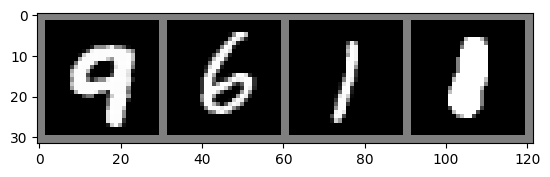

Labels: [9 6 1 1]


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of training data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Function to show images
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Show images
imshow(torchvision.utils.make_grid(images[:4]))
# Print labels
print('Labels:', labels[:4].numpy())